In [3]:
# magic command to display matplotlib plots inline within the ipython notebook webpage
%matplotlib inline

# import necessary modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm, matplotlib.font_manager as fm

In [5]:
# load the gps coordinate data, using the date as the full set's index
# the data files are encoded as utf-8: specify so to prevent matplotlib from choking on diacritics
df = pd.read_csv('C:/Users/18095/Desktop/PTUA/Lab/PTUA2026/Lab05/data/summer-travel-gps-full.csv', encoding='utf-8', index_col='date', parse_dates=True)
rs = pd.read_csv('C:/Users/18095/Desktop/PTUA/Lab/PTUA2026/Lab05/data/summer-travel-gps-dbscan.csv', encoding='utf-8')

In [7]:
df.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [8]:
rs.head()

,lat,lon,date,city,country
0,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
1,38.781775,-9.137544,05/14/2014 15:11,Lisbon,Portugal
2,38.771939,-9.128911,05/14/2014 15:41,Lisbon,Portugal
3,38.742987,-9.147780,05/14/2014 16:11,Lisbon,Portugal
4,38.693780,-9.206363,05/15/2014 14:19,Lisbon,Portugal


In [9]:
# Q1: Can you draw a bar chart for the most visited countries by using matplotlib and seaborn? You can use the df dataframe.
# Please style the chart to make it look nicer
# such as figsize, width, alpha, color, edgecolor, grid, xlim, and ylim
country_counts = df['country'].value_counts()
country_counts


country
Spain                     646
Portugal                  256
Germany                   225
Czech Republic            130
Poland                    104
Turkey                     94
Greece                     82
Montenegro                 51
Macedonia (FYROM)          34
Croatia                    30
Kosovo                     30
Albania                    29
Bosnia and Herzegovina     26
Serbia                     15
United Kingdom              7
Name: count, dtype: int64

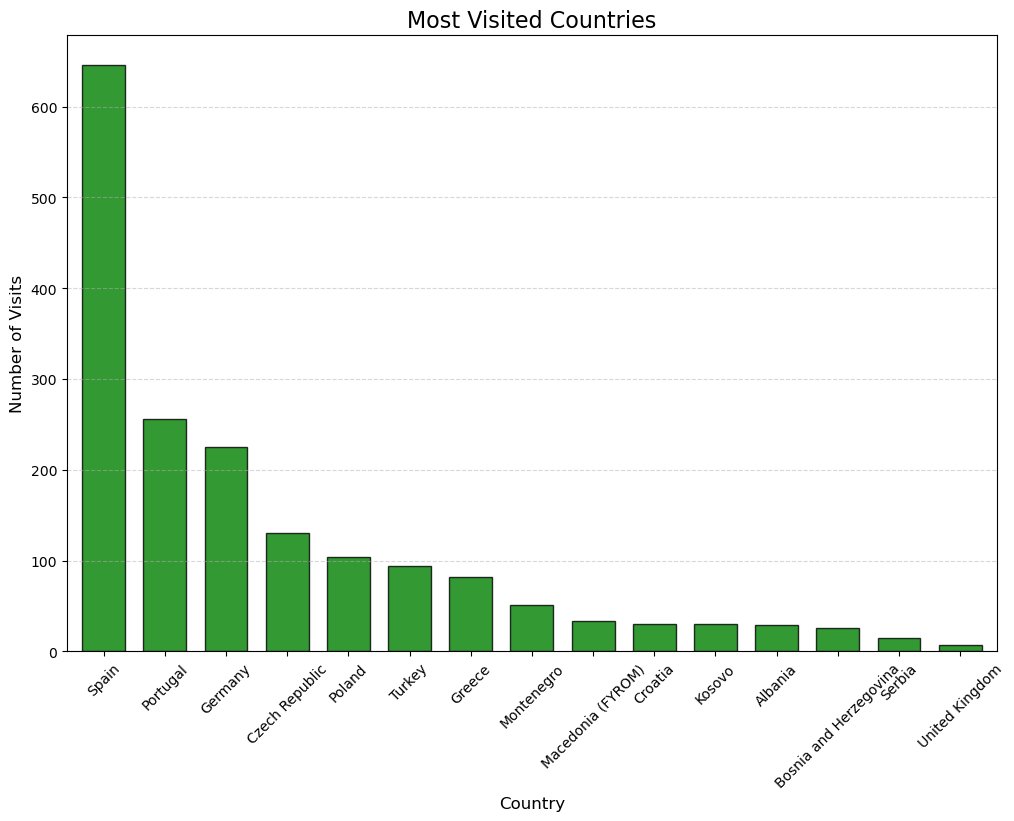

In [14]:
import matplotlib.pyplot as plt

country_counts.plot(kind='bar',
                   figsize=(12,8),
                   width=0.7,
                   color='green',
                   edgecolor='black',
                   alpha=0.8)

plt.title('Most Visited Countries', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Visits', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [19]:
# Q2: Draw the same bar chart, but now for the most visited cities instead of countries
city_counts = df['city'].value_counts()
city_counts

city
Barcelona                           632
Lisbon                              158
Tübingen                            131
Prague                               97
Istanbul                             94
                                   ... 
Ostrava                               1
Novy Bohumin                          1
Bytom                                 1
Ruda Slaska                           1
Nové Dvory (Kutná Hora District)      1
Name: count, Length: 113, dtype: int64

In [23]:
top_cities=city_counts.head(20)
top_cities

city
Barcelona                         632
Lisbon                            158
Tübingen                          131
Prague                             97
Istanbul                           94
Athens                             67
Krakow                             58
Porto                              58
Freiburg                           54
Kotor                              51
Ohrid                              34
Prizren                            30
Berat                              27
Kraków-Śródmieście                 26
Split                              23
Sarajevo                           15
Belgrade                           14
Kutna Hora                         12
Sintra                             12
Vila Nova de Gaia Municipality      9
Name: count, dtype: int64

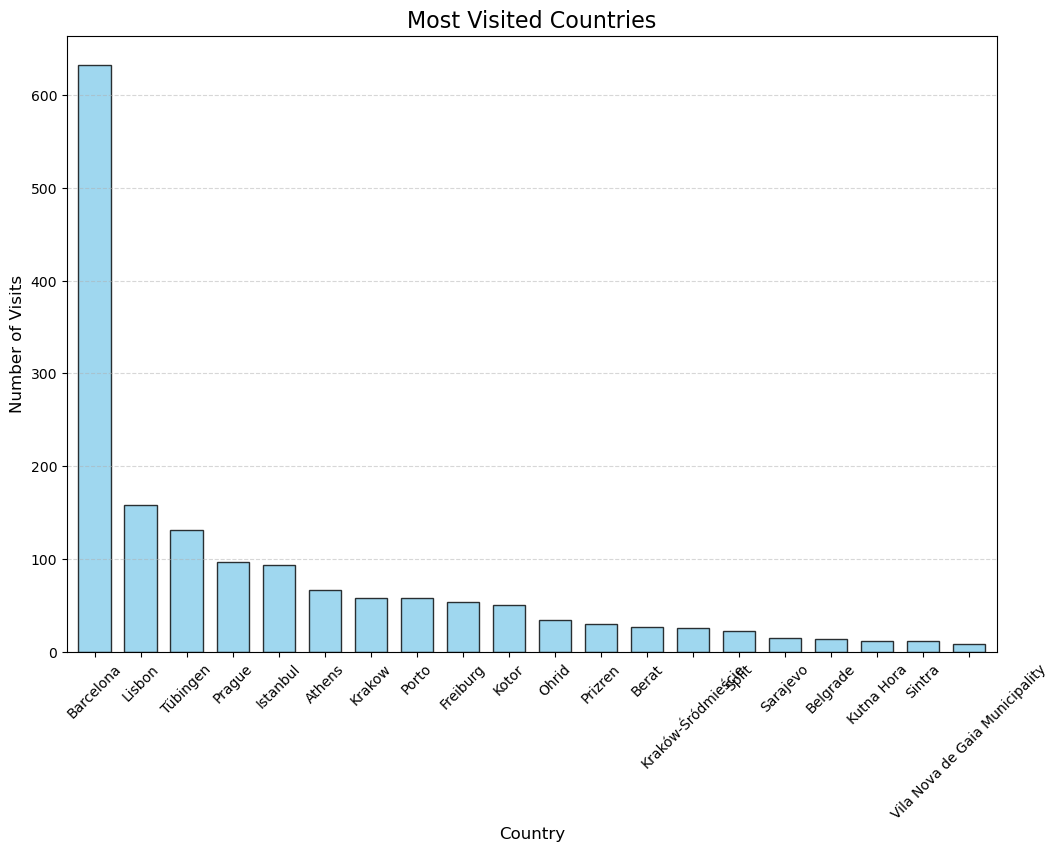

In [24]:
top_cities.plot(kind='bar',
                   figsize=(12,8),
                   width=0.7,
                   color='skyblue',
                   edgecolor='black',
                   alpha=0.8)

plt.title('Most Visited Countries', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Visits', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [27]:
# Q3: Draw a scatter plot the longitude and latitude data, with matplotlib and seaborn defaults. 
# You can use the rs dataframe.
# Please style the chart to make it look nicer with good size and alpha settings.
rs.columns

Index(['lat', 'lon', 'date', 'city', 'country'], dtype='object')

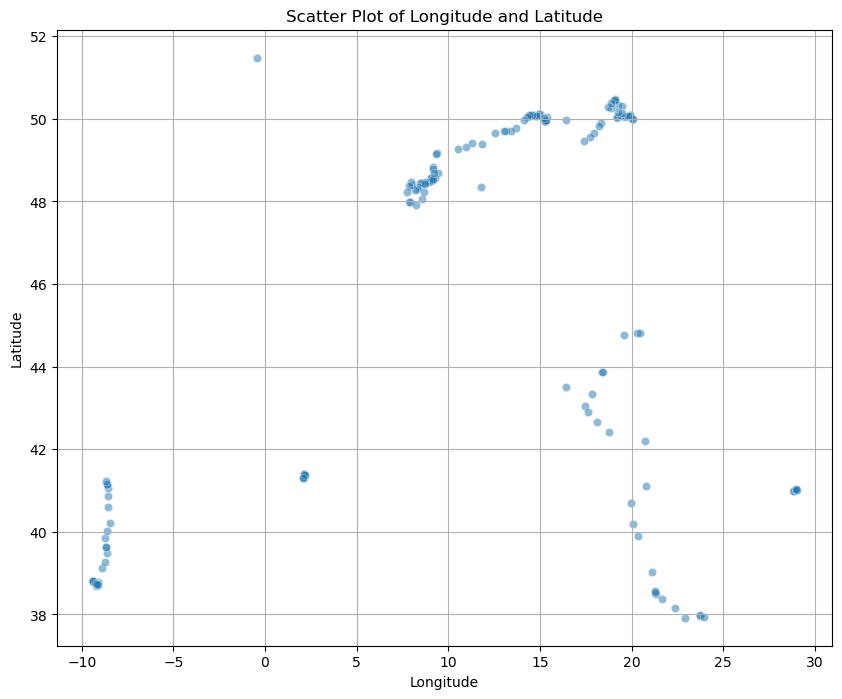

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.scatterplot(data=rs, x='lon', y='lat', alpha=0.5)

plt.title('Scatter Plot of Longitude and Latitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)

plt.show()


In [30]:
# get the count of records by date
countdata = df.groupby(df.index.date).size()
countdata.head()

2014-05-14    36
2014-05-15    61
2014-05-16    57
2014-05-17    64
2014-05-18    50
dtype: int64

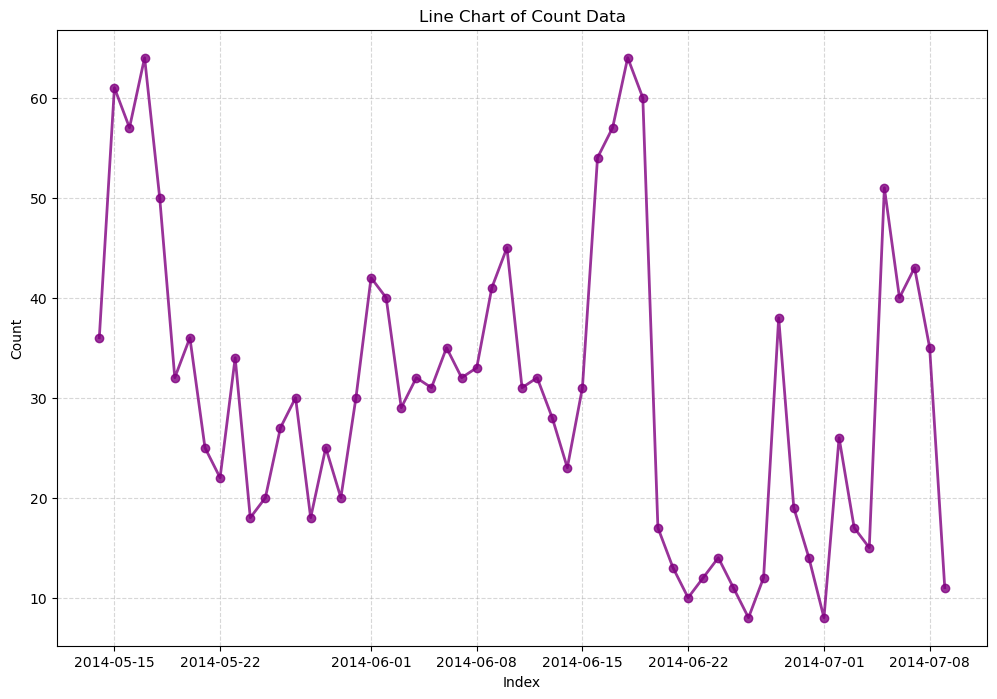

In [38]:
# Q4: Draw a  matplotlib and seaborn line chart from countdata. 
# Please style the chart to make it look nicer with good size and alpha settings. 
plt.figure(figsize=(12,8))
plt.plot(countdata.index, countdata.values, 
         color='purple', alpha=0.8, linewidth=2, marker='o')

plt.title('Line Chart of Count Data')
plt.xlabel('Index')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



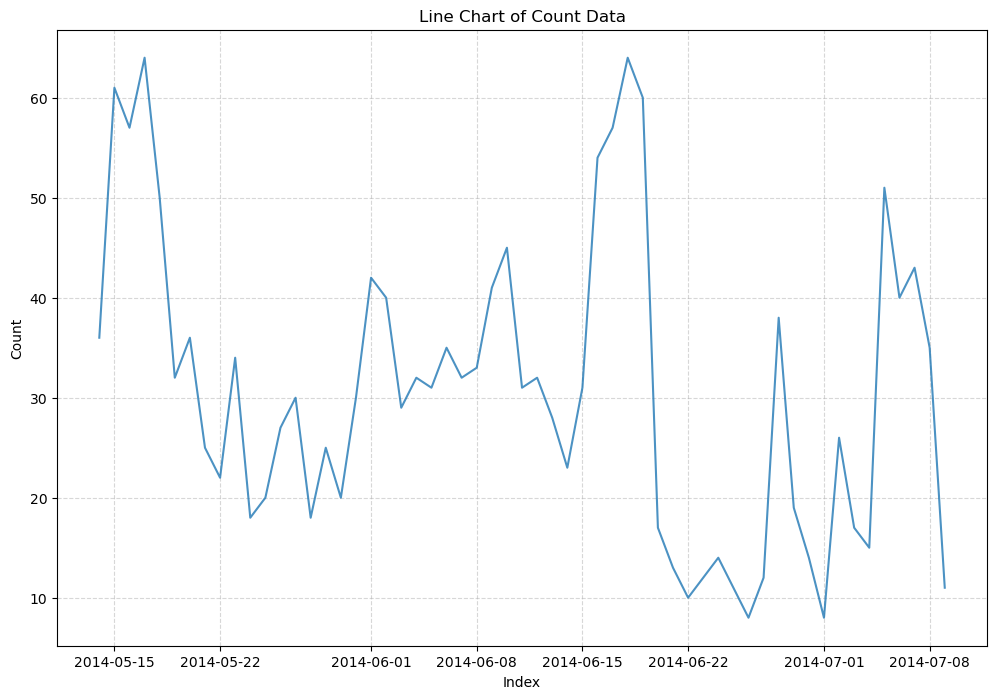

In [39]:
# Q5: Now you try: re-create the plot above with different line widths, colors, and point markers. 
# Play with moving the annotation labels around. Make the vertical tick marks 3 days apart instead of 5.
# experiment with a more advanced challenge like smoothing the line:
# - https://stackoverflow.com/questions/5283649/plot-smooth-line-with-pyplot
# - https://stackoverflow.com/questions/25825946/generating-smooth-line-graph-using-matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.lineplot(data=countdata, alpha=0.8)

plt.title('Line Chart of Count Data')
plt.xlabel('Index')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [40]:
cities = df['city'].value_counts()
print(cities.count())
cities.head()

113


city
Barcelona    632
Lisbon       158
Tübingen     131
Prague        97
Istanbul      94
Name: count, dtype: int64

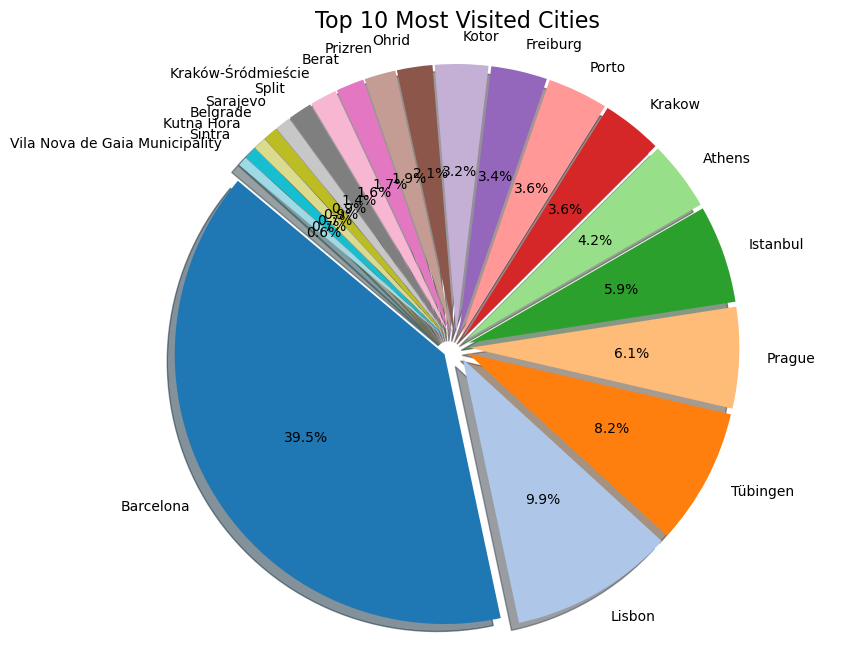

In [41]:
# Q6: draw a pie chart for cities.
# Please style the chart to make it look nicer. 

plt.figure(figsize=(10,8))

plt.pie(top_cities.values,
        labels=top_cities.index,
        autopct='%1.1f%%',  
        startangle=140,     
        shadow=True,         
        explode=[0.05]*len(top_cities),  
        colors=plt.cm.tab20.colors)      

plt.title('Top 10 Most Visited Cities', fontsize=16)
plt.axis('equal')  
plt.show()
